Analyze time-series fluorescence data from PURE (Protein synthesis Using Recombinant Elements) experiments. 

## Setup 

In [1]:
%load_ext autoreload
%autoreload 2
    
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Import the cdk platereader module
from cdk.analysis.cytosol import platereader as pr

# Set up plotting
pr.plot_setup()

## Load Data

In [2]:
# Specify file paths
data_file = "20260603-154318-cytation3-pure-timecourse-gfp-Cytosol-lifetime-test3-biotek-cdk.txt"
platemap_file = "20260603-platemap-Cytosol-Lifetime-R3.csv"


# Load data
data, platemap = pr.load_platereader_data(
    data_file=data_file,
    platemap_file=platemap_file,
    platereader="biotek-cdk"  # Options: "cytation", "envision", "biotek-cdk"
)

# Checkout first few rows
data.head()

,Time,Well,Data,Row,Column,Read,Clock Time,Reader,Date,Experiment Name,...,tRNA Vol (uL),DNA Vol (uL),RNase Inhib Vol (uL),CP Vol (uL),PPK Vol (uL),polyP Vol (uL),Mg-Ace Vol (uL),PEG Vol (uL),Water vol (uL),Rxn Volume (uL)
0,0 days 00:00:00,B2,37613,B,2,GFP-F-G35,2026-06-03 19:30:58,Cytation3,20260603,Cytosol-Lifetime-Test3,...,1.00,0.50,0.50,NaN,NaN,NaN,NaN,NaN,2.00,10
1,0 days 00:05:00,B2,47495,B,2,GFP-F-G35,2026-06-03 19:35:58,Cytation3,20260603,Cytosol-Lifetime-Test3,...,1.00,0.50,0.50,NaN,NaN,NaN,NaN,NaN,2.00,10
2,0 days 00:10:00,B2,46915,B,2,GFP-F-G35,2026-06-03 19:40:58,Cytation3,20260603,Cytosol-Lifetime-Test3,...,1.00,0.50,0.50,NaN,NaN,NaN,NaN,NaN,2.00,10
3,0 days 00:15:00,B2,46879,B,2,GFP-F-G35,2026-06-03 19:45:58,Cytation3,20260603,Cytosol-Lifetime-Test3,...,1.00,0.50,0.50,NaN,NaN,NaN,NaN,NaN,2.00,10
4,0 days 00:20:00,B2,46838,B,2,GFP-F-G35,2026-06-03 19:50:58,Cytation3,20260603,Cytosol-Lifetime-Test3,...,1.00,0.50,0.50,NaN,NaN,NaN,NaN,NaN,2.00,10


## Plot Raw Curves

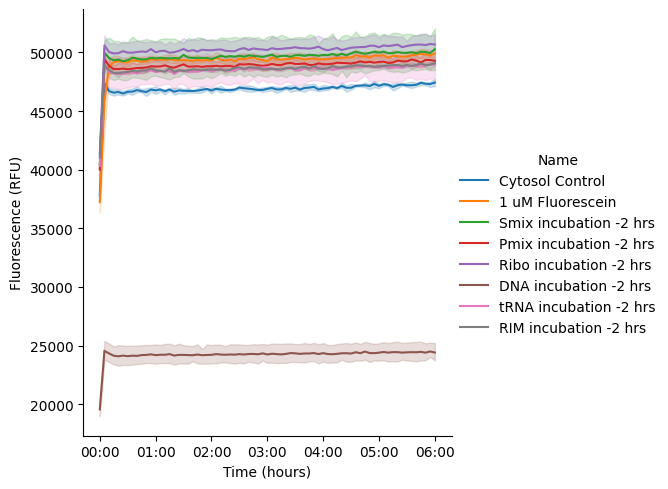

In [3]:
g = pr.plot_curves(data=data)
plt.savefig("kinetics")

## Normalize Data

In [4]:
data = pr.normalize_data_to_controls(data, ctrl_name = '1 uM Fluorescein')

Data Normalized to 1 uM Fluorescein in col data_normalized. The active column for subsequent operations is: data_normalized


Now replot your curves to see them normalized

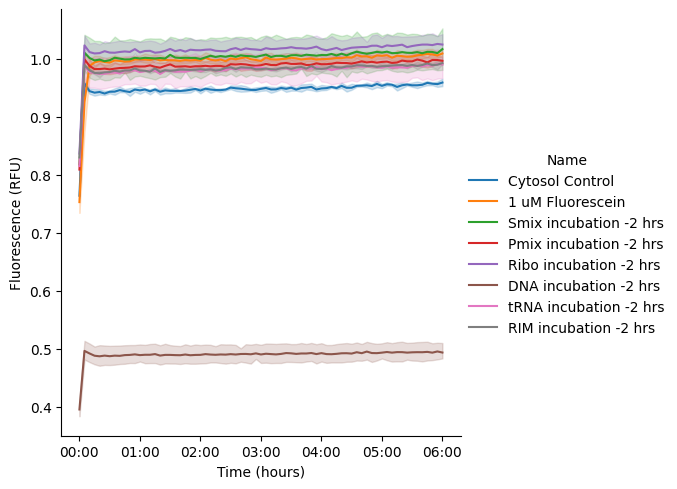

In [5]:
g = pr.plot_curves(data=data)
plt.savefig("kinetics-normalized")

## Kinetic Analysis
**Metrics extracted:**

  - **Vmax** (`Velocity Max`): Maximum rate of fluorescence increase (slope at inflection point)
  - **Lag time**: Time to reach the exponential phase
  - **Steady-state**: Final fluorescence level and time to reach 95% of asymptote
  - **Drift**: Rate of signal decay or increase after steady-state
  - **R²**: Goodness of fit

In [6]:
# Perform kinetic analysis using sigmoid_drift model
kinetics = pr.kinetic_analysis(
    data=data,
    group_by=['Well','Name'],  # Group by experimental condition
)

kinetics.head()

Calculating Kinetics


Velocity                        \
                                Time data_normalized   Max   
Well Name                                                    
B2   Cytosol Control          0 days            0.47 14.42   
B4   Cytosol Control          0 days            0.47 16.79   
B6   Cytosol Control          0 days            0.47 14.17   
D2   Smix incubation -2 hrs   0 days            0.51 13.43   
D4   Smix incubation -2 hrs   0 days            0.50 13.66   

                                                    Lag                  \
                                                   Time data_normalized   
Well Name                                                                 
B2   Cytosol Control        -1 days +23:58:02.144780044            0.13   
B4   Cytosol Control        -1 days +23:58:19.320008931            0.13   
B6   Cytosol Control        -1 days +23:58:01.010762764            0.13   
D2   Smix incubation -2 hrs -1 days +23:57:42.538539327            0.15   
D4   Smix incubation -2 hrs -1 days +23:57:48.830952633            0.14   

                                         Steady State                  \
                                                 Time data_normalized   
Well Name                                                               
B2   Cytosol Control        0 days 00:02:53.508751767            0.90   
B4   Cytosol Control        0 days 00:02:28.223045062            0.89   
B6   Cytosol Control        0 days 00:02:55.178274109            0.89   
D2   Smix incubation -2 hrs 0 days 00:03:22.373441467            0.97   
D4   Smix incubation -2 hrs 0 days 00:03:13.109627962            0.95   

                                                                           Fit  \
                                                                        params   
Well Name                                                                        
B2   Cytosol Control         [0.9442978257243599, 61.0919058379278, 0.0, -0...   
B4   Cytosol Control         [0.9392575427031279, 71.51371313692626, 0.0, -...   
B6   Cytosol Control         [0.9364107512346579, 60.50967438171754, 0.0, -...   
D2   Smix incubation -2 hrs  [1.0257403979132054, 52.37831727368629, 0.0, -...   
D4   Smix incubation -2 hrs  [0.9953014332697993, 54.89099863552549, 0.0, -...   

                                                  
                              R^2 drift good_fit  
Well Name                                         
B2   Cytosol Control        -1.07 -0.00    False  
B4   Cytosol Control        -1.54 -0.00    False  
B6   Cytosol Control        -1.36 -0.00    False  
D2   Smix incubation -2 hrs -2.04 -0.00    False  
D4   Smix incubation -2 hrs -1.64 -0.00    False

## Visualize Fits on Individual Wells

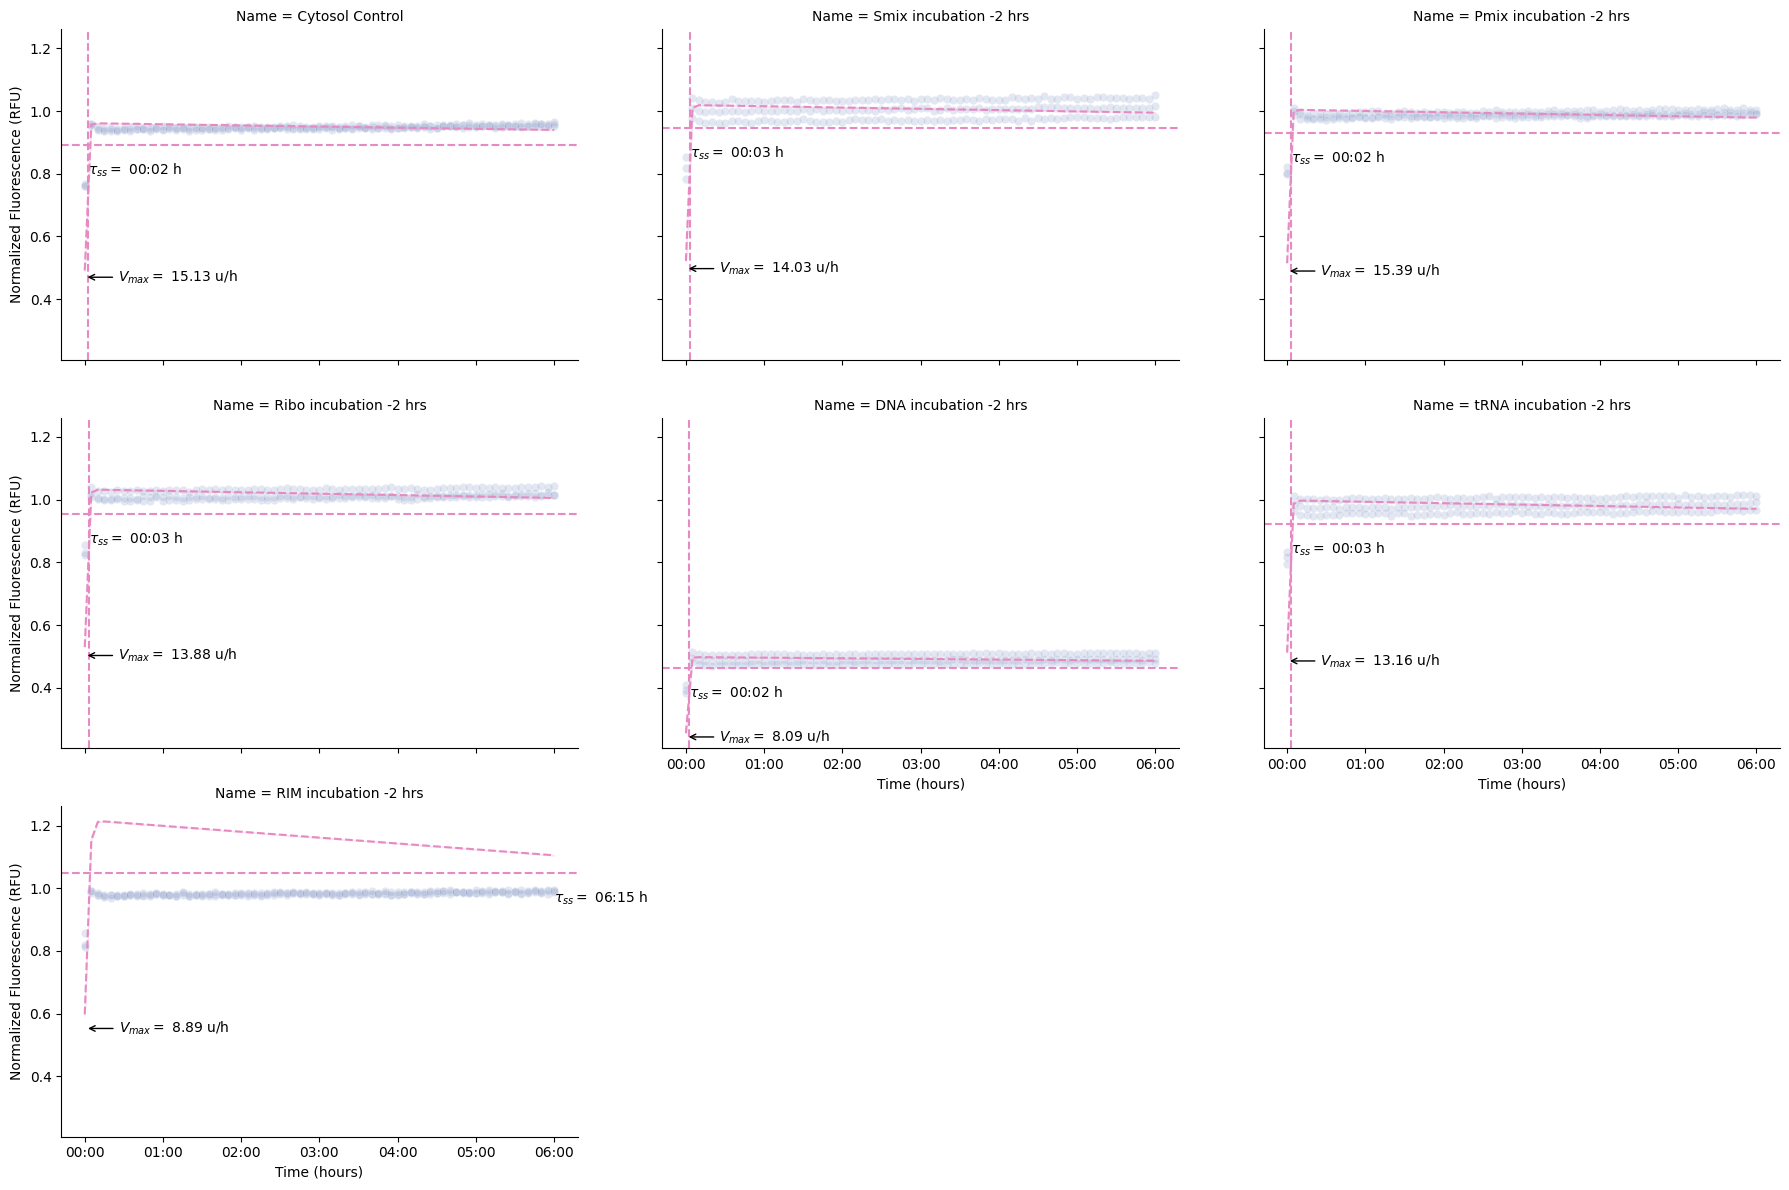

In [7]:
# Plot kinetic fits 
g = pr.plot_kinetics(data, kinetics=kinetics)

## Summary Plots

Calculating Kinetics


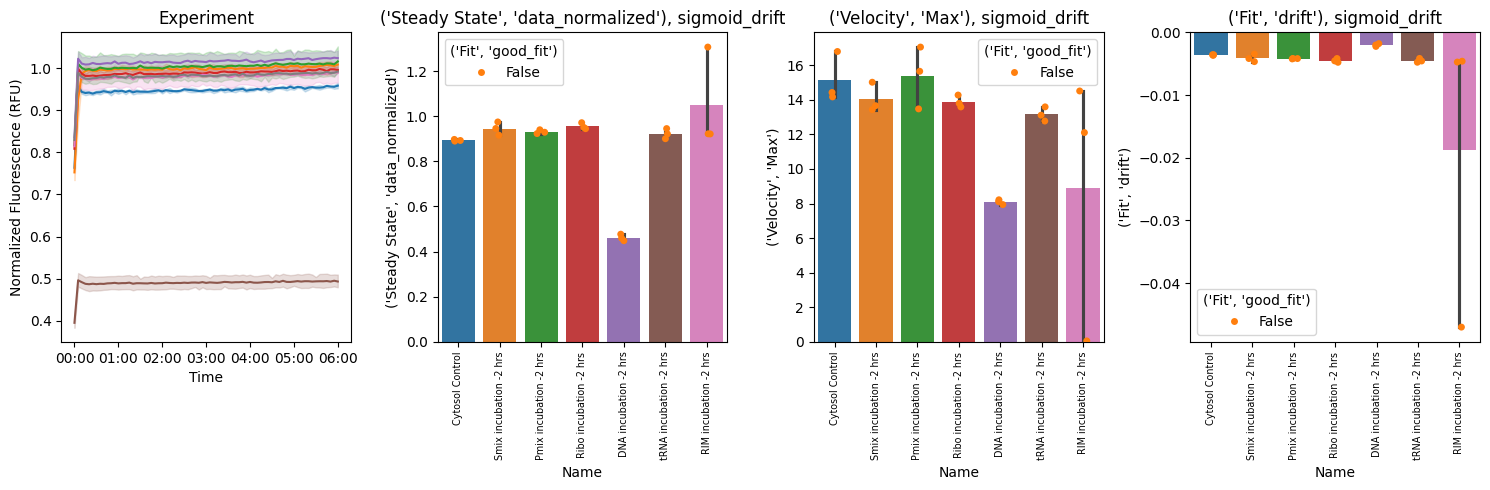

In [8]:
g = pr.plot_summary(data)
plt.savefig("summary")

---

## Key Metrics Explained

### 1. **Steady-State Level** (`Steady State, Data`)
- The final fluorescence value reached by the reaction
- Represents the total amount of protein produced
- Higher values indicate greater expression yield

### 2. **Maximum Velocity** (`Velocity, Max`)
- The steepest slope of the fluorescence curve (at the inflection point)
- Units: RFU per second
- Reflects the peak rate of protein synthesis
- Sensitive to enzyme activity, substrate availability, and reaction conditions

### 3. **Lag Time** (`Lag, Time`)
- Time before exponential fluorescence increase begins
- May reflect time for ribosome assembly or initial translation steps
- Shorter lag times suggest faster reaction initiation

### 4. **Drift** (`Fit, drift`)
- Rate of fluorescence change after reaching steady-state
- Positive drift: continued synthesis or aggregation
- Negative drift: photobleaching, protein degradation, or quenching
- Units: RFU per second

### 5. **R² Value** (`Fit, R^2`)
- Goodness of fit (0 to 1, higher is better)
- R² > 0.98 indicates excellent fit
- Poor fits may indicate noisy data, overflow errors, or non-sigmoid kinetics

---

## Tips and Troubleshooting

- **Overflow errors:** Wells with `OVRFLW` or `NaN` values are automatically excluded from fitting
- **Poor fits (low R²):** Inspect raw curves for anomalies (bubbles, evaporation, pipetting errors)
- **Drift:** Sometimes seen in kinetics curves; use `sigmoid_drift` model
- **Multiple replicates:** Always include technical replicates and report error bars
- **Comparing conditions:** Normalize or blank data consistently across all samples

---

## Next Steps

- Export kinetics results: `pr.export_kinetics(kinetics, 'results.csv')`
- Statistical analysis: Use `scipy.stats` or `statsmodels` for ANOVA/t-tests
- Parameter optimization: Vary Mg²⁺, K⁺, or other conditions to maximize Vmax or steady-state
- Mechanistic modeling: Fit ODE models to extract biological rate constants